In [44]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import KFold
import matplotlib.pyplot as plt
import time

In [45]:
df = pd.read_csv("Cars.csv")
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


In [46]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8128 non-null   str    
 1   year           8128 non-null   int64  
 2   selling_price  8128 non-null   int64  
 3   km_driven      8128 non-null   int64  
 4   fuel           8128 non-null   str    
 5   seller_type    8128 non-null   str    
 6   transmission   8128 non-null   str    
 7   owner          8128 non-null   str    
 8   mileage        7907 non-null   str    
 9   engine         7907 non-null   str    
 10  max_power      7913 non-null   str    
 11  torque         7906 non-null   str    
 12  seats          7907 non-null   float64
dtypes: float64(1), int64(3), str(9)
memory usage: 1.6 MB


In [47]:
df.describe()

,year,selling_price,km_driven,seats
count,8128.000000,8.128000e+03,8.128000e+03,7907.000000
mean,2013.804011,6.382718e+05,6.981951e+04,5.416719
std,4.044249,8.062534e+05,5.655055e+04,0.959588
min,1983.000000,2.999900e+04,1.000000e+00,2.000000
25%,2011.000000,2.549990e+05,3.500000e+04,5.000000
50%,2015.000000,4.500000e+05,6.000000e+04,5.000000
75%,2017.000000,6.750000e+05,9.800000e+04,5.000000
max,2020.000000,1.000000e+07,2.360457e+06,14.000000


In [48]:
df.isna().sum()

name               0
year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner              0
mileage          221
engine           221
max_power        215
torque           222
seats            221
dtype: int64

### Editing the target variable 
No log transformation in A3 as we are going to make it a classification target

In [49]:
X = df.drop("selling_price", axis=1)
y = df["selling_price"] 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 47)

In [50]:
X_train["owner"].values.unique()

<ArrowStringArray>
[         'First Owner',          'Third Owner',         'Second Owner',
 'Fourth & Above Owner',       'Test Drive Car']
Length: 5, dtype: str

In [51]:
owner_map = {
    'First Owner': 1,
    'Second Owner': 2,
    'Third Owner': 3,
    'Fourth & Above Owner': 4,
    'Test Drive Car': 5
}

X_train['owner'] = X_train['owner'].map(owner_map)
X_test['owner'] = X_test['owner'].map(owner_map)

#label encoder didn't map correctly hence this mapping

X_train.head()

,name,year,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
1155,Hyundai Grand i10 1.2 CRDi Sportz Option,2018,50000,Diesel,Individual,Manual,1,24.0 kmpl,1186 CC,73.97 bhp,190.24nm@ 1750-2250rpm,5.0
3263,Maruti Alto LXi,2009,70000,Petrol,Individual,Manual,3,19.7 kmpl,796 CC,46.3 bhp,62Nm@ 3000rpm,5.0
2754,Hyundai Santro Xing GLS,2010,90000,Petrol,Individual,Manual,1,17.92 kmpl,1086 CC,62.1 bhp,96.1Nm@ 3000rpm,5.0
5581,Hyundai i10 Magna 1.2 iTech SE,2013,40000,Petrol,Individual,Manual,1,20.36 kmpl,1197 CC,78.9 bhp,111.7Nm@ 4000rpm,5.0
4461,Hyundai Santro Sportz AMT BSIV,2018,10000,Petrol,Individual,Automatic,1,20.3 kmpl,1086 CC,68 bhp,99Nm@ 4500rpm,5.0


In [52]:
np.unique(X_train["owner"])

array([1, 2, 3, 4, 5])

In [53]:
X_train["fuel"].values.unique()

<ArrowStringArray>
['Diesel', 'Petrol', 'LPG', 'CNG']
Length: 4, dtype: str

In [54]:
X_train = X_train[~X_train["fuel"].isin(["LPG", "CNG"])]
X_test = X_test[~X_test["fuel"].isin(["LPG", "CNG"])]
X_train["fuel"].values.unique()

<ArrowStringArray>
['Diesel', 'Petrol']
Length: 2, dtype: str

In [55]:
X_train["mileage"]

1155     24.0 kmpl
3263     19.7 kmpl
2754    17.92 kmpl
5581    20.36 kmpl
4461     20.3 kmpl
           ...    
6728    22.54 kmpl
3336     20.0 kmpl
6471     21.1 kmpl
1926     16.1 kmpl
5255     16.8 kmpl
Name: mileage, Length: 5626, dtype: str

In [56]:
X_train["mileage"] = X_train["mileage"].str.replace(" kmpl", "", regex=False).astype("float")
X_test["mileage"] = X_test["mileage"].str.replace(" kmpl", "", regex=False).astype("float")
X_train["mileage"]

1155    24.00
3263    19.70
2754    17.92
5581    20.36
4461    20.30
        ...  
6728    22.54
3336    20.00
6471    21.10
1926    16.10
5255    16.80
Name: mileage, Length: 5626, dtype: float64

In [57]:
X_train["engine"]

1155    1186 CC
3263     796 CC
2754    1086 CC
5581    1197 CC
4461    1086 CC
         ...   
6728    1396 CC
3336     999 CC
6471     814 CC
1926     796 CC
5255    1984 CC
Name: engine, Length: 5626, dtype: str

In [58]:
X_train["engine"] = X_train["engine"].str.replace(" CC", "", regex=False).astype("float")
X_test["engine"] = X_test["engine"].str.replace(" CC", "", regex=False).astype("float")
X_train["engine"]

1155    1186.0
3263     796.0
2754    1086.0
5581    1197.0
4461    1086.0
         ...  
6728    1396.0
3336     999.0
6471     814.0
1926     796.0
5255    1984.0
Name: engine, Length: 5626, dtype: float64

In [59]:
X_train["max_power"]

1155    73.97 bhp
3263     46.3 bhp
2754     62.1 bhp
5581     78.9 bhp
4461       68 bhp
          ...    
6728    88.76 bhp
3336       72 bhp
6471     55.2 bhp
1926       37 bhp
5255      150 bhp
Name: max_power, Length: 5626, dtype: str

In [60]:
X_train["max_power"] = X_train["max_power"].str.replace(" bhp", "", regex=False).astype("float")
X_test["max_power"] = X_test["max_power"].str.replace(" bhp", "", regex=False).astype("float")
X_train["max_power"]

1155     73.97
3263     46.30
2754     62.10
5581     78.90
4461     68.00
         ...  
6728     88.76
3336     72.00
6471     55.20
1926     37.00
5255    150.00
Name: max_power, Length: 5626, dtype: float64

In [61]:
X_train["brand"] = X_train["name"].str.split().str[0]
X_train.insert(1, "brand", X_train.pop("brand"))
X_train = X_train.drop(columns=["name"])

X_test["brand"] = X_test["name"].str.split().str[0]
X_test.insert(1, "brand", X_test.pop("brand"))
X_test = X_test.drop(columns=["name"])

X_train.head()

,brand,year,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
1155,Hyundai,2018,50000,Diesel,Individual,Manual,1,24.00,1186.0,73.97,190.24nm@ 1750-2250rpm,5.0
3263,Maruti,2009,70000,Petrol,Individual,Manual,3,19.70,796.0,46.30,62Nm@ 3000rpm,5.0
2754,Hyundai,2010,90000,Petrol,Individual,Manual,1,17.92,1086.0,62.10,96.1Nm@ 3000rpm,5.0
5581,Hyundai,2013,40000,Petrol,Individual,Manual,1,20.36,1197.0,78.90,111.7Nm@ 4000rpm,5.0
4461,Hyundai,2018,10000,Petrol,Individual,Automatic,1,20.30,1086.0,68.00,99Nm@ 4500rpm,5.0


In [62]:
X_test = X_test.drop("torque", axis=1)
X_train = X_train.drop("torque", axis=1)

X_train.head()

,brand,year,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats
1155,Hyundai,2018,50000,Diesel,Individual,Manual,1,24.00,1186.0,73.97,5.0
3263,Maruti,2009,70000,Petrol,Individual,Manual,3,19.70,796.0,46.30,5.0
2754,Hyundai,2010,90000,Petrol,Individual,Manual,1,17.92,1086.0,62.10,5.0
5581,Hyundai,2013,40000,Petrol,Individual,Manual,1,20.36,1197.0,78.90,5.0
4461,Hyundai,2018,10000,Petrol,Individual,Automatic,1,20.30,1086.0,68.00,5.0


In [63]:
X_train = X_train[X_train["owner"] != 5]
X_test = X_test[X_test["owner"] != 5]

X_train.head()

,brand,year,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats
1155,Hyundai,2018,50000,Diesel,Individual,Manual,1,24.00,1186.0,73.97,5.0
3263,Maruti,2009,70000,Petrol,Individual,Manual,3,19.70,796.0,46.30,5.0
2754,Hyundai,2010,90000,Petrol,Individual,Manual,1,17.92,1086.0,62.10,5.0
5581,Hyundai,2013,40000,Petrol,Individual,Manual,1,20.36,1197.0,78.90,5.0
4461,Hyundai,2018,10000,Petrol,Individual,Automatic,1,20.30,1086.0,68.00,5.0


In [64]:
X_train[X_train["owner"] == 5]

,brand,year,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats


In [65]:
print("Shape of X_train: ", X_train.shape)
print("Shape of X_test: ", X_test.shape)
print("Shape of y_train: ", y_train.shape)
print("Shape of y_test: ", y_test.shape)

Shape of X_train:  (5624, 11)
Shape of X_test:  (2404, 11)
Shape of y_train:  (5689,)
Shape of y_test:  (2439,)


### Edit to create buckets

In [66]:
#To match rows of X and y
y_train = y_train.loc[X_train.index]
y_test = y_test.loc[X_test.index]


# Used qcut on training data to find balanced quartiles without class imbalance
y_train, bin_edges = pd.qcut(y_train, q=4, labels=False, retbins=True) # Also, edges computed from TRAIN only, applied same edges to test TO AVOID LEAKAGE
y_test = pd.cut(y_test, bins=bin_edges, labels=False, include_lowest=True)


# drop test rows whose price fell outside train's observed range (causes NaN)
valid_mask = ~pd.isna(y_test)
X_test = X_test[valid_mask]
y_test = y_test[valid_mask]

print("Bucket edges (price):", bin_edges)
print("Shape of X_train: ", X_train.shape)
print("Shape of X_test: ", X_test.shape)
print("Shape of y_train: ", y_train.shape)
print("Shape of y_test: ", y_test.shape)
print("\nTrain class distribution:\n", pd.Series(y_train).value_counts().sort_index())
print("Test class distribution:\n", pd.Series(y_test).value_counts().sort_index())

Bucket edges (price): [  29999.  254999.  450000.  685000. 6000000.]
Shape of X_train:  (5624, 11)
Shape of X_test:  (2402, 11)
Shape of y_train:  (5624,)
Shape of y_test:  (2402,)

Train class distribution:
 selling_price
0    1413
1    1455
2    1352
3    1404
Name: count, dtype: int64
Test class distribution:
 selling_price
0.0    585
1.0    641
2.0    599
3.0    577
Name: count, dtype: int64


In [67]:
X_train.isna().sum()

brand             0
year              0
km_driven         0
fuel              0
seller_type       0
transmission      0
owner             0
mileage         145
engine          145
max_power       140
seats           145
dtype: int64

In [68]:
X_test.isna().sum()

brand            0
year             0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
mileage         69
engine          69
max_power       68
seats           69
dtype: int64

<Figure size 400x300 with 0 Axes>

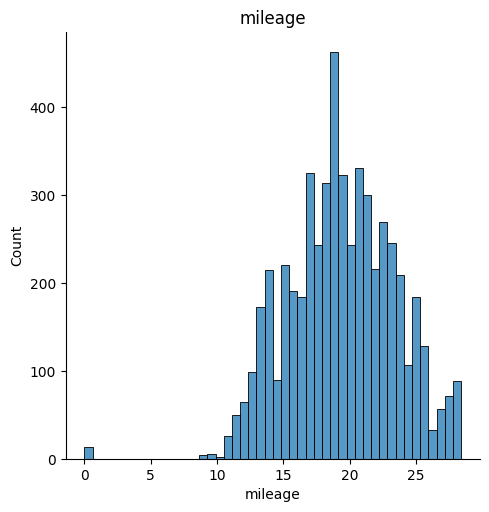

<Figure size 400x300 with 0 Axes>

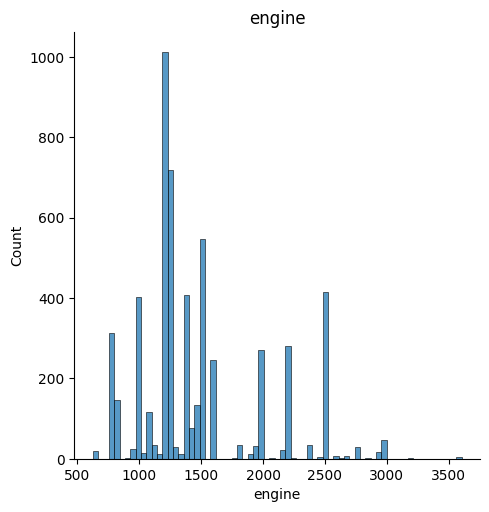

<Figure size 400x300 with 0 Axes>

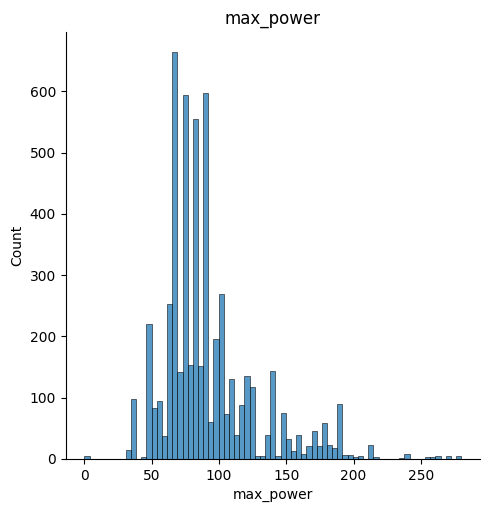

In [69]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in ['mileage', 'engine', 'max_power']:
    plt.figure(figsize=(4, 3))
    sns.displot(x=X_train[col])
    plt.title(col)
    plt.show()


mileage's distribution looks like normal distribution but engine and max power are right-skewed

<Figure size 400x300 with 0 Axes>

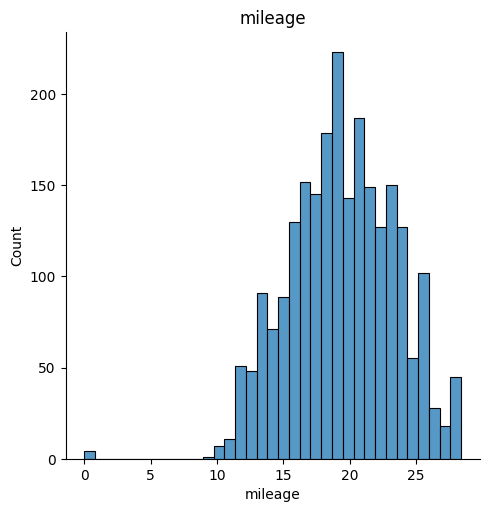

<Figure size 400x300 with 0 Axes>

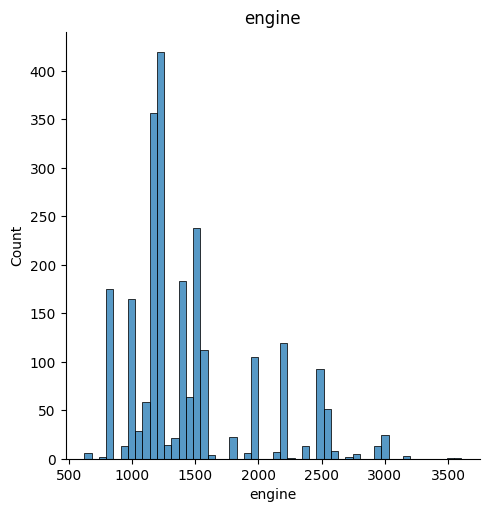

<Figure size 400x300 with 0 Axes>

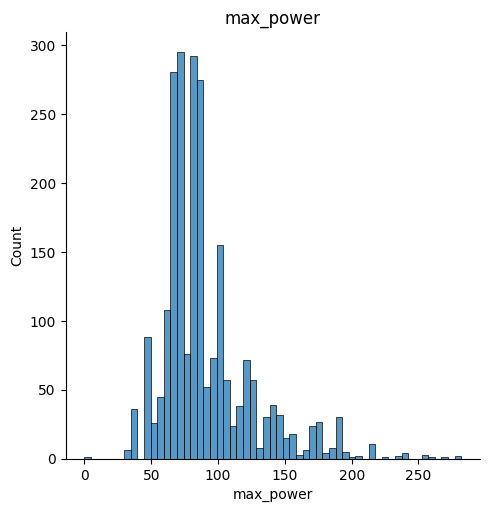

In [70]:
for col in ['mileage', 'engine', 'max_power']:
    plt.figure(figsize=(4, 3))
    sns.displot(x=X_test[col])
    plt.title(col)
    plt.show()

same thing in X_test as well

In [71]:
from sklearn.impute import SimpleImputer

median_cols = ["mileage", "engine", "max_power"]
mode_cols = ["seats"]

median_imputer = SimpleImputer(strategy="median")
X_train[median_cols] = median_imputer.fit_transform(X_train[median_cols])
X_test[median_cols] = median_imputer.transform(X_test[median_cols])

mode_imputer = SimpleImputer(strategy="most_frequent") # since seats is a discrete column and taking mean/median could cause like float values
X_train[mode_cols] = mode_imputer.fit_transform(X_train[mode_cols])
X_test[mode_cols] = mode_imputer.transform(X_test[mode_cols])

X_train.isna().sum()

brand           0
year            0
km_driven       0
fuel            0
seller_type     0
transmission    0
owner           0
mileage         0
engine          0
max_power       0
seats           0
dtype: int64

In [72]:
# Capturing for dash app
brand_options = sorted(X_train["brand"].unique().tolist())
fuel_options = sorted(X_train["fuel"].unique().tolist())
seller_type_options = sorted(X_train["seller_type"].unique().tolist())
transmission_options = sorted(X_train["transmission"].unique().tolist())

X_train = pd.get_dummies(X_train, columns=["brand", "fuel", "seller_type", "transmission"], drop_first=True)
X_test = pd.get_dummies(X_test, columns=["brand", "fuel", "seller_type", "transmission"], drop_first=True)

X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0) # to match the columns in both X_test and X_train

In [73]:
from sklearn.preprocessing import StandardScaler

scale_cols = ["year", "km_driven","mileage","engine", "max_power","seats"]
scaler = StandardScaler()
X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test[scale_cols]  = scaler.transform(X_test[scale_cols])

In [74]:
print("Shape of X_train: ", X_train.shape)
print("Shape of X_test: ", X_test.shape)
print("Shape of y_train: ", y_train.shape)
print("Shape of y_test: ", y_test.shape)

Shape of X_train:  (5624, 42)
Shape of X_test:  (2402, 42)
Shape of y_train:  (5624,)
Shape of y_test:  (2402,)


In [75]:
feature_names = list(X_train.columns) 

In [76]:
X_train_np = X_train.values.astype(float)
X_test_np = X_test.values.astype(float)
y_train = y_train.values
y_test = y_test.values


# add intercept column (same trick as 03 - Regularization.ipynb)
intercept_train = np.ones((X_train_np.shape[0], 1))
X_train = np.concatenate((intercept_train, X_train_np), axis=1)
intercept_test = np.ones((X_test_np.shape[0], 1))
X_test = np.concatenate((intercept_test, X_test_np), axis=1)

### One-hot Encode the y_train since it was just 0,1,2,3 before, and since the order doesn't matter here

In [77]:
k = 4
m = X_train.shape[0]
y_train_encoded = np.zeros((m, k))
for c in range(k):
    y_train_encoded[np.where(y_train == c), c] = 1

print("y_train_encoded shape:", y_train_encoded.shape)

y_train_encoded shape: (5624, 4)


### modifying the 02-MultinomialLogisticRegression code

In [78]:
class LogisticRegression:
    
    def __init__(self, k, n, method, alpha = 0.001, max_iter=5000, use_penalty=False, l=0.01):
        self.k = k
        self.n = n
        self.alpha = alpha
        self.max_iter = max_iter
        self.method = method
        # New additions for penalty of Ridge Regression
        self.use_penalty = use_penalty
        self.l = l
    
    def fit(self, X, Y):
        self.W = np.random.rand(self.n, self.k)
        self.losses = []
        
        if self.method == "batch":
            start_time = time.time()
            for i in range(self.max_iter):
                loss, grad =  self.gradient(X, Y)
                self.losses.append(loss)
                self.W = self.W - self.alpha * grad
                if i % 500 == 0:
                    print(f"Loss at iteration {i}", loss)
            print(f"time taken: {time.time() - start_time}")
            
        elif self.method == "minibatch":
            start_time = time.time()
            batch_size = int(0.3 * X.shape[0])
            for i in range(self.max_iter):
                ix = np.random.randint(0, X.shape[0]) 
                batch_X = X[ix:ix+batch_size]
                batch_Y = Y[ix:ix+batch_size]
                loss, grad = self.gradient(batch_X, batch_Y)
                self.losses.append(loss)
                self.W = self.W - self.alpha * grad
                if i % 500 == 0:
                    print(f"Loss at iteration {i}", loss)
            print(f"time taken: {time.time() - start_time}")
            
        elif self.method == "sto":
            start_time = time.time()
            list_of_used_ix = []
            for i in range(self.max_iter):
                idx = np.random.randint(X.shape[0])
                while i in list_of_used_ix:
                    idx = np.random.randint(X.shape[0])
                X_train = X[idx, :].reshape(1, -1)
                Y_train = Y[idx]
                loss, grad = self.gradient(X_train, Y_train)
                self.losses.append(loss)
                self.W = self.W - self.alpha * grad
                
                list_of_used_ix.append(i)
                if len(list_of_used_ix) == X.shape[0]:
                    list_of_used_ix = []
                if i % 500 == 0:
                    print(f"Loss at iteration {i}", loss)
            print(f"time taken: {time.time() - start_time}")
            
        else:
            raise ValueError('Method must be one of the followings: "batch", "minibatch" or "sto".')
        
        
    def gradient(self, X, Y):
        m = X.shape[0]
        h = self.h_theta(X, self.W)
        h_clipped = np.clip(h, 1e-15, 1 - 1e-15)  # avoid log(0) -> nan, doesn't affect the gradient
        loss = - np.sum(Y*np.log(h_clipped)) / m
        error = h - Y
        grad = self.softmax_grad(X, error)

        # Ridge / L2 penalty
        # loss += l * sum(theta^2) 
        # grad += + l * 2 * theta 
        if self.use_penalty:
            loss = loss + self.l * np.sum(self.W ** 2)
            grad = grad + self.l * 2 * self.W

        
        return loss, grad

    def softmax(self, theta_t_x):
        # numerically stable softmax: subtracting the row max doesn't change theresult mathematically, but keeps every exponent <= 0, preventing overflow
        z = theta_t_x - np.max(theta_t_x, axis=1, keepdims=True)
        return np.exp(z) / np.sum(np.exp(z), axis=1, keepdims=True)

    def softmax_grad(self, X, error):
        return  X.T @ error

    def h_theta(self, X, W):
        '''
        Input:
            X shape: (m, n)
            w shape: (n, k)
        Returns:
            yhat shape: (m, k)
        '''
        return self.softmax(X @ W)
    
    def predict(self, X_test):
        return np.argmax(self.h_theta(X_test, self.W), axis=1)
    
    def plot(self):
        plt.plot(np.arange(len(self.losses)) , self.losses, label = "Train Losses")
        plt.title("Losses")
        plt.xlabel("epoch")
        plt.ylabel("losses")
        plt.legend()


    # Metrics calculation for evaluation (for A3)

    def accuracy(self, y_true, y_pred):
        return np.mean(y_true == y_pred)
 
    def precision(self, y_true, y_pred, c):
        tp = np.sum((y_pred == c) & (y_true == c))
        fp = np.sum((y_pred == c) & (y_true != c))
        return tp / (tp + fp) if (tp + fp) > 0 else 0.0
 
    def recall(self, y_true, y_pred, c):
        tp = np.sum((y_pred == c) & (y_true == c))
        fn = np.sum((y_pred != c) & (y_true == c))
        return tp / (tp + fn) if (tp + fn) > 0 else 0.0
 
    def f1_score(self, y_true, y_pred, c):
        p = self.precision(y_true, y_pred, c)
        r = self.recall(y_true, y_pred, c)
        return 2 * p * r / (p + r) if (p + r) > 0 else 0.0
 
    def macro_precision(self, y_true, y_pred):
        return np.mean([self.precision(y_true, y_pred, c) for c in range(self.k)])
 
    def macro_recall(self, y_true, y_pred):
        return np.mean([self.recall(y_true, y_pred, c) for c in range(self.k)])
 
    def macro_f1(self, y_true, y_pred):
        return np.mean([self.f1_score(y_true, y_pred, c) for c in range(self.k)])
 
    def weighted_precision(self, y_true, y_pred):
        weights = [np.sum(y_true == c) / len(y_true) for c in range(self.k)]
        return sum(w * self.precision(y_true, y_pred, c) for w, c in zip(weights, range(self.k)))
 
    def weighted_recall(self, y_true, y_pred):
        weights = [np.sum(y_true == c) / len(y_true) for c in range(self.k)]
        return sum(w * self.recall(y_true, y_pred, c) for w, c in zip(weights, range(self.k)))
 
    def weighted_f1(self, y_true, y_pred):
        weights = [np.sum(y_true == c) / len(y_true) for c in range(self.k)]
        return sum(w * self.f1_score(y_true, y_pred, c) for w, c in zip(weights, range(self.k)))

    def classification_report_scratch(self, y_true, y_pred):
            """Classification_report layout but made from the methods above, for comparison"""
            print(f"{'':>12}{'precision':>12}{'recall':>12}{'f1-score':>12}{'support':>12}")
            for c in range(self.k):
                support = np.sum(y_true == c)
                print(f"{c:>12}{self.precision(y_true,y_pred,c):>12.4f}"
                      f"{self.recall(y_true,y_pred,c):>12.4f}"
                      f"{self.f1_score(y_true,y_pred,c):>12.4f}{support:>12}")
            print()
            print(f"{'accuracy':>12}{'':>24}{self.accuracy(y_true,y_pred):>12.4f}{len(y_true):>12}")
            print(f"{'macro avg':>12}{self.macro_precision(y_true,y_pred):>12.4f}"
                  f"{self.macro_recall(y_true,y_pred):>12.4f}"
                  f"{self.macro_f1(y_true,y_pred):>12.4f}{len(y_true):>12}")
            print(f"{'weighted avg':>12}{self.weighted_precision(y_true,y_pred):>12.4f}"
                  f"{self.weighted_recall(y_true,y_pred):>12.4f}"
                  f"{self.weighted_f1(y_true,y_pred):>12.4f}{len(y_true):>12}")

### Testing the metric functions

In [79]:
n = X_train.shape[1]  # number of features (including intercept)
k = 4                 # number of price-bucket classes

model = LogisticRegression(k, n, method="batch", alpha=0.1, max_iter=5000, use_penalty=False)
model.fit(X_train, y_train_encoded)
yhat = model.predict(X_test)

Loss at iteration 0 1.6504481721036863


Loss at iteration 500 12.653116955395612
Loss at iteration 1000 12.220596274620199
Loss at iteration 1500 12.11834066030359
Loss at iteration 2000 12.072758328269176
Loss at iteration 2500 12.141328962799067
Loss at iteration 3000 12.048059480600966
Loss at iteration 3500 12.17257942478493
Loss at iteration 4000 12.158020644839164
Loss at iteration 4500 12.14603407470715
time taken: 7.446252346038818


### Comparison with sklearn and the scratch ones

In [80]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
print(classification_report(y_test, yhat))

              precision    recall  f1-score   support

         0.0       0.96      0.64      0.77       585
         1.0       0.52      0.90      0.66       641
         2.0       0.74      0.08      0.15       599
         3.0       0.65      0.94      0.77       577

    accuracy                           0.64      2402
   macro avg       0.72      0.64      0.59      2402
weighted avg       0.71      0.64      0.58      2402



In [88]:
model.classification_report_scratch(y_test, yhat)

               precision      recall    f1-score     support
           0      0.8655      0.8359      0.8504         585
           1      0.6598      0.6958      0.6773         641
           2      0.6132      0.6194      0.6163         599
           3      0.8165      0.7868      0.8014         577

    accuracy                              0.7327        2402
   macro avg      0.7388      0.7345      0.7364        2402
weighted avg      0.7359      0.7327      0.7341        2402


We can confirm that the values from scratch and the sklearn are the same

**Support** in Classification Report is just the number of occurrences of each class in the dataset

### Now, we find the best parameters for the model

In [82]:
import mlflow
import numpy as np

# === Local MLflow setup (same pattern as A2 -- no remote server needed per the announcement) ===
mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("st127145-a3")

n = X_train.shape[1]   # number of features (including intercept)
k = 4                  # number of price-bucket classes

methods = ["batch", "minibatch", "sto"]
penalties = [False, True]
l_values = [0.01, 0.1]              # only used when penalty=True
alphas = [0.0001, 0.00005, 0.00001]  # small range -- see reasoning markdown cell
max_iter = 5000

total_runs = 0
for method in methods:
    for use_penalty in penalties:
        l_options = l_values if use_penalty else [0]
        for l in l_options:
            for alpha in alphas:
                run_name = f"{method}_penalty{use_penalty}_l{l}_alpha{alpha}"
                with mlflow.start_run(run_name=run_name):
                    mlflow.log_param("method", method)
                    mlflow.log_param("use_penalty", use_penalty)
                    mlflow.log_param("l", l)
                    mlflow.log_param("alpha", alpha)
                    mlflow.log_param("max_iter", max_iter)

                    np.random.seed(42)  # reproducibility across runs
                    model = LogisticRegression(
                        k, n, method=method, alpha=alpha,
                        max_iter=max_iter, use_penalty=use_penalty, l=l
                    )
                    model.fit(X_train, y_train_encoded)
                    yhat = model.predict(X_test)

                    acc = model.accuracy(y_test, yhat)
                    macro_p = model.macro_precision(y_test, yhat)
                    macro_r = model.macro_recall(y_test, yhat)
                    macro_f1 = model.macro_f1(y_test, yhat)
                    weighted_p = model.weighted_precision(y_test, yhat)
                    weighted_r = model.weighted_recall(y_test, yhat)
                    weighted_f1 = model.weighted_f1(y_test, yhat)
                    final_loss = model.losses[-1]

                    mlflow.log_metric("accuracy", acc)
                    mlflow.log_metric("macro_precision", macro_p)
                    mlflow.log_metric("macro_recall", macro_r)
                    mlflow.log_metric("macro_f1", macro_f1)
                    mlflow.log_metric("weighted_precision", weighted_p)
                    mlflow.log_metric("weighted_recall", weighted_r)
                    mlflow.log_metric("weighted_f1", weighted_f1)
                    mlflow.log_metric("final_loss", final_loss)

                    total_runs += 1
                    print(f"[{total_runs}] {run_name}: acc={acc:.4f} macro_f1={macro_f1:.4f}")

print(f"\nDone -- {total_runs} runs logged.")

Loss at iteration 0 1.456619920042351
Loss at iteration 500 0.6005089707602851
Loss at iteration 1000 0.581305362012279
Loss at iteration 1500 0.5741162599489106
Loss at iteration 2000 0.5705964389123251
Loss at iteration 2500 0.5686148196547942
Loss at iteration 3000 0.5673878821264708
Loss at iteration 3500 0.5665711639065583
Loss at iteration 4000 0.5659949324096117
Loss at iteration 4500 0.5655683651769696
time taken: 5.746967315673828
[1] batch_penaltyFalse_l0_alpha0.0001: acc=0.7331 macro_f1=0.7368
Loss at iteration 0 1.456619920042351
Loss at iteration 500 0.6294434494548939
Loss at iteration 1000 0.6005442963466311
Loss at iteration 1500 0.5881950367940718
Loss at iteration 2000 0.5813174275096078
Loss at iteration 2500 0.577011835163593
Loss at iteration 3000 0.5741222089298168
Loss at iteration 3500 0.5720869578309324
Loss at iteration 4000 0.5705998478084503
Loss at iteration 4500 0.5694805803020495
time taken: 6.380310773849487
[2] batch_penaltyFalse_l0_alpha5e-05: acc=0.72

In [83]:
runs = mlflow.search_runs(experiment_names=["st127145-a3"])
best_row = (
    runs.drop_duplicates(subset=[c for c in runs.columns if c.startswith("params.")])
        .sort_values("metrics.macro_f1", ascending=False)
        .iloc[0]
)
print(best_row[["params.method", "params.use_penalty", "params.l",
                 "params.alpha", "metrics.accuracy", "metrics.macro_f1", "metrics.weighted_f1"]])

params.method             batch
params.use_penalty        False
params.l                      0
params.alpha             0.0001
metrics.accuracy       0.733139
metrics.macro_f1       0.736826
metrics.weighted_f1    0.734556
Name: 26, dtype: object


In [84]:
final_model = LogisticRegression(
    k, n,
    method=best_row["params.method"],
    alpha=float(best_row["params.alpha"]),
    max_iter=10000,  # more than the sweep used, now that we know this config is stable
    use_penalty=(best_row["params.use_penalty"] == "True"),
    l=float(best_row["params.l"])
)
final_model.fit(X_train, y_train_encoded)
yhat = final_model.predict(X_test)

Loss at iteration 0 1.6763234689108342
Loss at iteration 500 0.602026159234379
Loss at iteration 1000 0.5819211874254603
Loss at iteration 1500 0.5744383408537965
Loss at iteration 2000 0.570793376370886
Loss at iteration 2500 0.5687500407759996
Loss at iteration 3000 0.5674898515806179
Loss at iteration 3500 0.5666537956404749
Loss at iteration 4000 0.566065297030494
Loss at iteration 4500 0.5656301202828116
Loss at iteration 5000 0.565294710180366
Loss at iteration 5500 0.5650270350739632
Loss at iteration 6000 0.5648070913868923
Loss at iteration 6500 0.5646219092096094
Loss at iteration 7000 0.5644627943281763
Loss at iteration 7500 0.5643237413829847
Loss at iteration 8000 0.5642004879244307
Loss at iteration 8500 0.564089932685909
Loss at iteration 9000 0.5639897677554889
Loss at iteration 9500 0.5638982400667877
time taken: 12.52133059501648


In [85]:
print("Accuracy:       ", final_model.accuracy(y_test, yhat))
print("Macro Precision:", final_model.macro_precision(y_test, yhat))
print("Macro Recall:   ", final_model.macro_recall(y_test, yhat))
print("Macro F1:       ", final_model.macro_f1(y_test, yhat))
print("Weighted F1:    ", final_model.weighted_f1(y_test, yhat))

Accuracy:        0.7327227310574521
Macro Precision: 0.7387549855897451
Macro Recall:    0.7344698249091403
Macro F1:        0.7363557298232948
Weighted F1:     0.7340622993285675


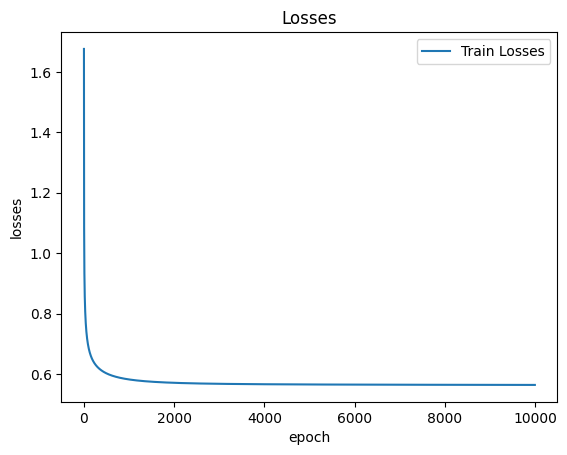

In [86]:
final_model.plot()

In [87]:
import sys, os, joblib

sys.path.insert(0, "./app/code")
from logistic_regression import LogisticRegression  # make sure final_model is built from THIS import

os.makedirs("./app/code/models", exist_ok=True)

# the classification model
joblib.dump(final_model, "./app/code/models/model_v3.pkl")

# bucket edges -- needed so the app can show a human-readable price RANGE, not just "class 2"
joblib.dump(bin_edges, "./app/code/models/bin_edges.pkl")

# same feature columns as A2 (preprocessing pipeline is unchanged)
joblib.dump(feature_names, "./app/code/models/feature_columns_v3.pkl")

print("Saved:", os.listdir("./app/code/models"))

ImportError: cannot import name 'LogisticRegression' from 'logistic_regression' (c:\AIT\ML\A3\app/code\logistic_regression.py)